<a href="https://colab.research.google.com/github/guzik1234/DataScienceCwiczenia/blob/main/python_pandas/Por%C3%B3wnanieDoSQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd

In [2]:
url=('https://archive.isc.uci.edu/,l/machine-learning-databases/00352/Online%20Tetails.xlsx')

In [6]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
retails = pd.read_excel(url)

In [7]:
retails.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
cols = [col for col in retails.columns]
print(cols)

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [9]:
retails.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
retails.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [12]:
retails = retails[retails['CustomerID'].notnull()]

In [15]:
retails['CustomerID'] = retails['CustomerID'].apply(lambda x: str(int(x)))
print(retails['CustomerID'])

0         17850
1         17850
2         17850
3         17850
4         17850
          ...  
541904    12680
541905    12680
541906    12680
541907    12680
541908    12680
Name: CustomerID, Length: 406829, dtype: object


/tmp/ipykernel_2301/4137458338.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retails['CustomerID'] = retails['CustomerID'].apply(lambda x: str(int(x)))


In [17]:
retails = retails[retails['Quantity'] > 0]

In [18]:
query = retails

In [21]:
"""SELECT * FROM retails WHERE CustomerID='17850'"""

querry= retails[retails['CustomerID']=='17850']
_querry = retails.query("CustomerID=='17850'")


In [22]:
"SELECT * fROM retial WHERE CustomerID='17850' and UnitPrice >5"

querry = retails[(retails['CustomerID']=='17850') & (retails['UnitPrice']>5)]
querry
_querry = retails.query("CustomerID=='17850' and UnitPrice>5")
_querry

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom
58,536373,82486,WOOD S/3 CABINET ANT WHITE FINISH,4,2010-12-01 09:02:00,6.95,17850,United Kingdom
63,536373,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 09:02:00,7.65,17850,United Kingdom
75,536375,82486,WOOD S/3 CABINET ANT WHITE FINISH,4,2010-12-01 09:32:00,6.95,17850,United Kingdom
80,536375,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 09:32:00,7.65,17850,United Kingdom
288,536396,82486,WOOD S/3 CABINET ANT WHITE FINISH,4,2010-12-01 10:51:00,6.95,17850,United Kingdom
293,536396,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 10:51:00,7.65,17850,United Kingdom
294,536396,22803,IVORY EMBROIDERED QUILT,2,2010-12-01 10:51:00,35.75,17850,United Kingdom
425,536406,82486,WOOD S/3 CABINET ANT WHITE FINISH,4,2010-12-01 11:33:00,6.95,17850,United Kingdom
430,536406,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 11:33:00,7.65,17850,United Kingdom


In [23]:
"SELECT * FROM retails WHERE CustomerID='17850' or Country='France'"

querry = retails[(retails['CustomerID']=='17850') | (retails['Country']=='France')]
_querry = retails.query("CustomerID=='17850' or Country=='France'")

In [27]:
"""SELECT * FROM retails WHERE INvoiceNo is null;"""

# Corrected: Call isnull() and use '~' for 'is not null'
_querry = retails[~retails['InvoiceNo'].isnull()]
query = retails[retails['InvoiceNo'].isnull()]


In [29]:
"""SELECT * FROM retails WHERE INvoiceNo is not null;"""

_querry = retails[~retails['InvoiceNo'].notnull()]
query = retails[retails['InvoiceNo'].notnull()]


<Axes: xlabel='Country'>

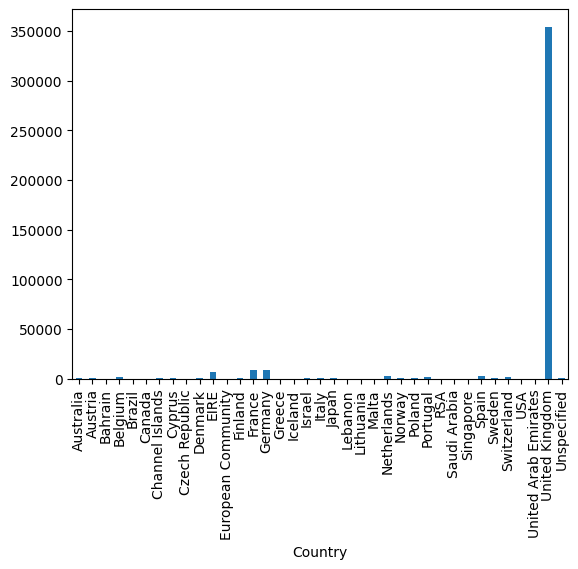

In [31]:
"""SELECT CustomerID, count(*) FROM retial Group BY cutomerID"""

_cust_id = retails.groupby('CustomerID').size()
country = retails.groupby('Country').size()
country.plot(kind='bar')

In [32]:
retails['Revenue'] = retails['Quantity'] * retails['UnitPrice']


/tmp/ipykernel_2301/3232981326.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retails['Revenue'] = retails['Quantity'] * retails['UnitPrice']


In [34]:
"""SELECT CustomerID, avg('Revenue'), count(*) FROM retial GROUP BY CustomerID;"""
result = retails.groupby('CustomerID').agg({'Revenue': np.mean, 'InvoiceNo': np.size}).rename(columns={'Revenue': 'AvgRevenue', 'InvoiceNo': 'Count', 'CustomerID': 'CountCustomer'})
result

/tmp/ipykernel_2301/3277257063.py:2: FutureWarning: The provided callable <function mean at 0x7a0e4f35e480> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result = retails.groupby('CustomerID').agg({'Revenue': np.mean, 'InvoiceNo': np.size}).rename(columns={'Revenue': 'AvgRevenue', 'InvoiceNo': 'Count', 'CustomerID': 'CountCustomer'})


,AvgRevenue,Count
CustomerID,,
12346,77183.600000,1
12347,23.681319,182
12348,57.975484,31
12349,24.076027,73
12350,19.670588,17
...,...,...
18280,18.060000,10
18281,11.545714,7
18282,14.837500,12


In [36]:
retails['InvoiceDay'] = retails['InvoiceDate'].dt.day

/tmp/ipykernel_2301/867421656.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retails['InvoiceDay'] = retails['InvoiceDate'].dt.day


/tmp/ipykernel_2301/191560521.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  querry = retails.groupby('InvoiceDay').agg({'Revenue': sum})


<Axes: title={'center': 'Sales by day'}, xlabel='InvoiceDay'>

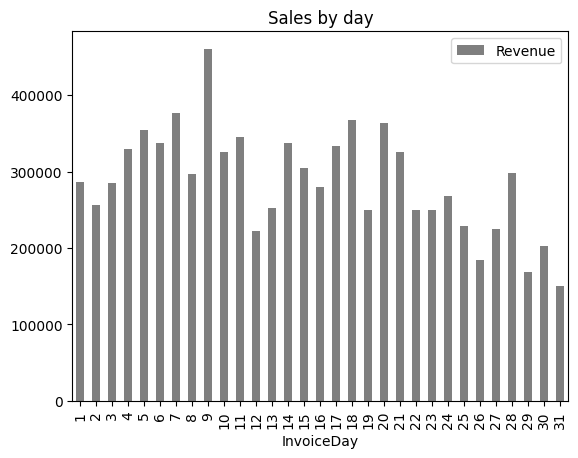

In [38]:
querry = retails.groupby('InvoiceDay').agg({'Revenue': sum})
querry.plot(kind='bar', color='black', alpha=0.5, title='Sales by day')

/tmp/ipykernel_2301/4148830143.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_9['Hour'] = day_9['InvoiceDate'].dt.hour
/tmp/ipykernel_2301/4148830143.py:5: FutureWarning: The provided callable <function sum at 0x7a0e4f35d3a0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  querry = day_9.groupby('Hour').agg({'Revenue': np.sum})


<Axes: title={'center': 'Sales by hour'}, xlabel='Hour'>

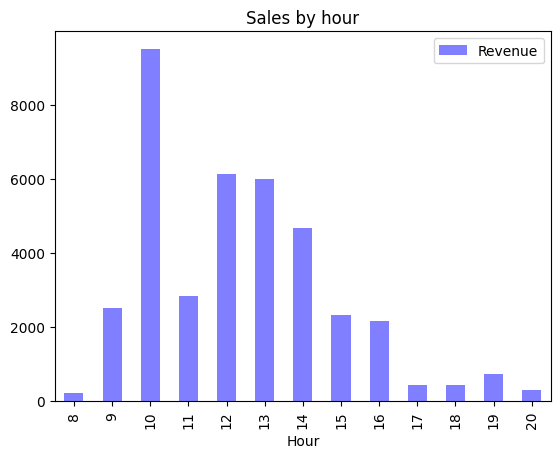

In [43]:
mask = (retails['InvoiceDate'] >= pd.to_datetime('2010-12-09')) & (retails['InvoiceDate'] < pd.to_datetime('2010-12-10'))
day_9 = retails[mask]
day_9['Hour'] = day_9['InvoiceDate'].dt.hour

querry = day_9.groupby('Hour').agg({'Revenue': np.sum})
querry.plot(kind='bar', color='blue', alpha=0.5, title='Sales by hour')

In [44]:
"""SELECT * FROM retail ORDERBY QUantity DESC LIMIT 5;"""

querrry = retails.nlargest(5, columns='Quantity')
querrry

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceDay
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.6,9
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.6,18
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256,United Kingdom,0.0,25
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901,United Kingdom,1008.0,27
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135,United Kingdom,3096.0,27


In [45]:
"""SELECT * FROM retails ORDER BY Quantity LIMIT 10"""

query = retails.nsmallest(10, columns='Quantity')


In [46]:
"""SELECT * FROM retail ORDERBY QUantity DESC LIMIT 5;"""

querrry = retails.sort_values(by='Quantity', ascending=False).head(5)
querrry

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceDay
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.6,9
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.6,18
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256,United Kingdom,0.0,25
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901,United Kingdom,1008.0,27
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135,United Kingdom,3096.0,27
